In [122]:
import zeus
import numpy as np
from scipy.special import erf

In [2]:
EMISSION_LINES = {
    # --- SERIE DE BALMER ---
    "Hepsilon": 3971.198,
    "Hdelta": 4102.892,
    "Hgamma": 4341.684,
    "Hbeta": 4862.683,
    "Halpha": 6564.614,

    # --- HELIO NEUTRO ---
    "HeI_A": 4472.735,
    "HeI_B": 5017.077,
    "HeI_C": 5877.243,
    "HeI_D": 7067.195,

    # --- OXÍGENO ---
    "OIII_A": 4960.295,
    "OIII_B": 5008.240,
    "OII_A": 7321.936,
    "OII_B": 7332.210,

    # --- NITRÓGENO ---
    "NII_A": 6549.860,
    "NII_B": 6585.270,

    # --- AZUFRE ---
    "SIII": 6313.805,
    "SII_A": 6718.290,
    "SII_B": 6732.670,

    # --- ARGÓN ---
    "ArIII": 7137.770,
}

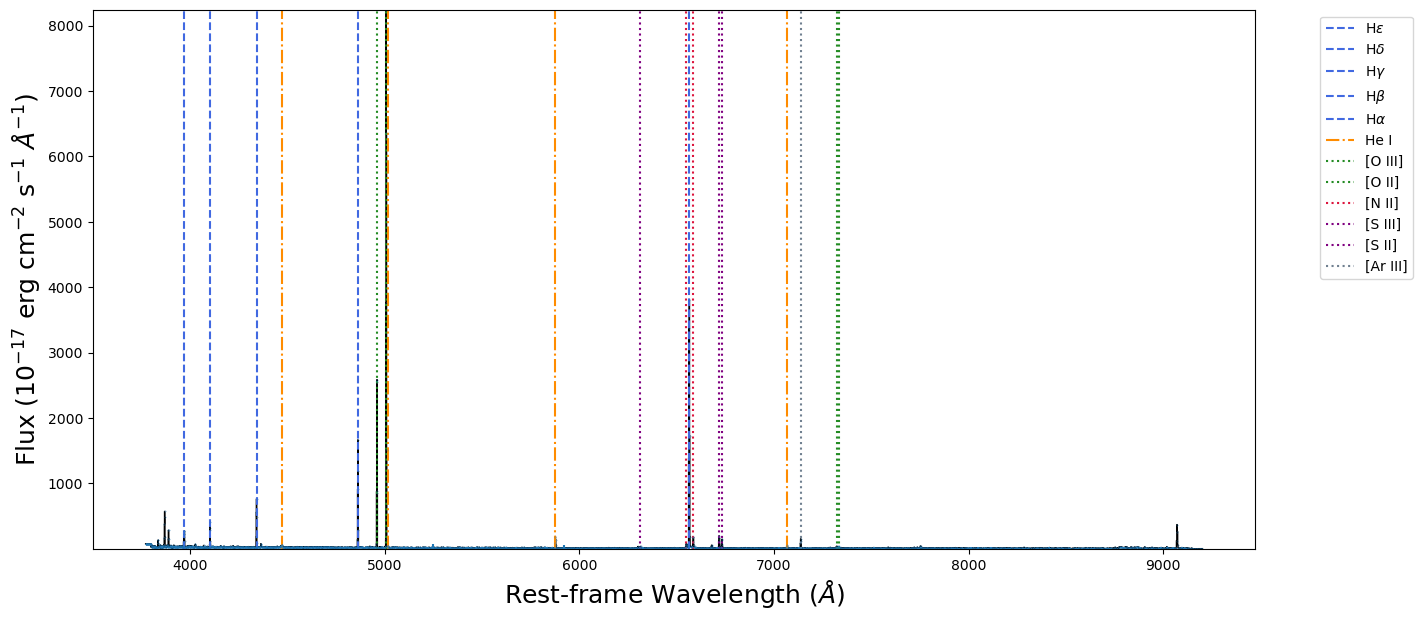

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
from astropy.modeling import models,fitting

# Abrir el espectro
spec = fits.open('~/Data_storageHII/GEHR_specDR7/NGC3319B-zcorI.fit')
header = spec[0].header
data = spec[0].data
flux = data[0]
ivar = data[1]

# USAR LOS KEYWORDS ACTUALIZADOS POR IRAF
# CRVAL1 es el log10 de la longitud de onda inicial corregida por dopcor
wav_start = header['CRVAL1'] 
# CD1_1 o CDELT1 es el paso logarítmico (0.0001)
wav_step = header['CD1_1']  

# Reconstruir el eje de longitud de onda en VACÍO y en REPOSO
# La fórmula es: 10**(log10_lambda)
log_wave = wav_start + wav_step * np.arange(len(flux))
wave_rest = 10**log_wave


def corregir_ivar_con_promedio(ivar, flux, ventana_limpia=None):
    """
    Reemplaza NaNs e ivar <= 0 con el valor mediano de los pixeles buenos.
    
    Parameters:
    -----------
    ivar : array_like
        Array de varianza inversa original.
    flux : array_like
        Array de flujo (se usa para identificar NaNs en el flujo también).
    ventana_limpia : tuple, opcional
        Indices (start, end) de una zona del espectro que sea puro continuo 
        para calcular un promedio más preciso.
    """
    ivar_corr = np.copy(ivar)
    
    # 1. Identificar pixeles con datos válidos
    mask_buenos = np.isfinite(ivar) & (ivar > 0) & np.isfinite(flux)
    
    # 2. Calcular el valor de ivar representativo
    if ventana_limpia is not None:
        # Usamos una zona específica del continuo si se proporciona
        start, end = ventana_limpia
        ivar_promedio = np.nanmedian(ivar[start:end][ivar[start:end] > 0])
    else:
        # Usamos la mediana de todos los pixeles buenos en la ventana actual
        ivar_promedio = np.nanmedian(ivar[mask_buenos])
    
    # 3. Si no hay ningún pixel bueno (caso extremo), usamos un valor muy bajo
    if np.isnan(ivar_promedio):
        ivar_promedio = 1e-5
        
    # 4. Reemplazar valores defectuosos
    mask_malos = ~mask_buenos
    ivar_corr[mask_malos] = ivar_promedio
    
    return ivar_corr

ivar_c = corregir_ivar_con_promedio(ivar, flux, ventana_limpia=None)

x_data = wave_rest
y_data = flux
ivar_data = ivar_c

# 3. Calcular flux_err (sigma) de forma segura
y_err = 1.0 / np.sqrt(ivar_data)

# Graficar
fig = plt.figure(figsize=(15,7))
plt.step(x_data, y_data, where='mid', color='k', lw=1)
plt.errorbar(x=x_data, y=y_data, yerr=y_err, fmt='o',ms=0.2)#where='mid', color='orange', lw=0.5, alpha =0.7)


# --- SERIE DE BALMER (HIDRÓGENO) - Color: RoyalBlue ---
plt.axvline(3971.198, color='royalblue', linestyle='--', label=r'H$\epsilon$')
plt.axvline(4102.892, color='royalblue', linestyle='--', label=r'H$\delta$')
plt.axvline(4341.684, color='royalblue', linestyle='--', label=r'H$\gamma$')
plt.axvline(4862.683, color='royalblue', linestyle='--', label=r'H$\beta$')
plt.axvline(6564.614, color='royalblue', linestyle='--', label=r'H$\alpha$')

# --- HELIO NEUTRO (He I) - Color: DarkOrange ---
plt.axvline(4472.735, color='darkorange', linestyle='-.', label='He I')
plt.axvline(5017.077, color='darkorange', linestyle='-.', label='He I')
plt.axvline(5877.243, color='darkorange', linestyle='-.', label='He I')
plt.axvline(7067.195, color='darkorange', linestyle='-.', label='He I')

# --- OXÍGENO ([O II], [O III]) - Color: ForestGreen ---
plt.axvline(4960.295, color='forestgreen', linestyle=':', label=r'[O III]')
plt.axvline(5008.240, color='forestgreen', linestyle=':', label=r'[O III]')
plt.axvline(7321.936, color='forestgreen', linestyle=':', label=r'[O II]')
plt.axvline(7332.210, color='forestgreen', linestyle=':', label=r'[O II]')

# --- NITRÓGENO ([N II]) - Color: Crimson ---
plt.axvline(6549.860, color='crimson', linestyle=':', label=r'[N II]')
plt.axvline(6585.270, color='crimson', linestyle=':', label=r'[N II]')

# --- AZUFRE ([S II], [S III]) - Color: Purple ---
plt.axvline(6313.805, color='purple', linestyle=':', label=r'[S III]')
plt.axvline(6718.290, color='purple', linestyle=':', label=r'[S II]')
plt.axvline(6732.670, color='purple', linestyle=':', label=r'[S II]')

# --- ARGÓN ([Ar III]) - Color: SlateGray ---
plt.axvline(7137.770, color='slategray', linestyle=':', label=r'[Ar III]')

# Opcional: Para evitar etiquetas duplicadas en la leyenda
handles, labels = plt.gca().get_legend_handles_labels()
by_label = dict(zip(labels, handles))

#Complejo $[OIII] + He I$
#Complejo $H\alpha + [NII]$
#Complejo $H\epsilon + [Ne III]$
#Doblete $[SII]$
#Doblete $[OII]$

plt.yscale('linear')
plt.ylim(1,max(flux))
#plt.xlim(4800,4900)
#plt.xlim(7000,7500)
plt.xlabel(r"Rest-frame Wavelength ($\AA$)", fontsize=18)
plt.ylabel(r"Flux ($10^{-17}$ erg cm$^{-2}$ s$^{-1}$ $\AA^{-1}$)", fontsize=18)
plt.legend(by_label.values(), by_label.keys(), bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()


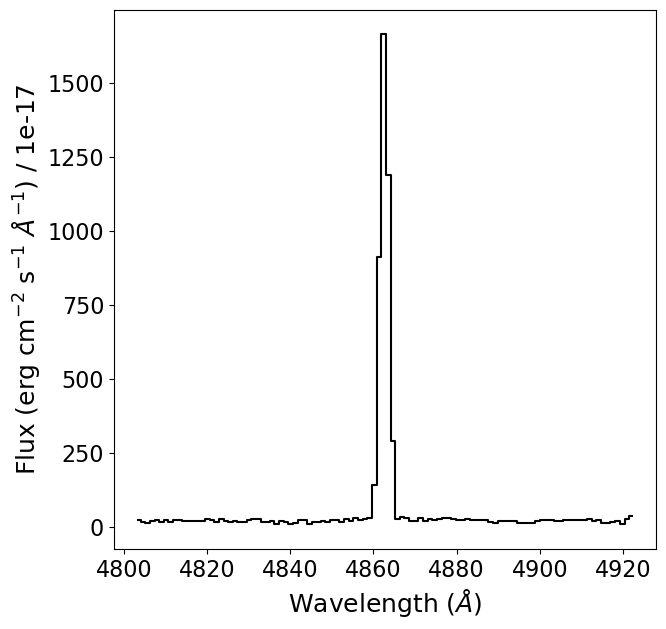

In [173]:
# select indices in wavelength array that correspond to our selected
#wavelength range, and use this to slice the array of fluxes
hb_sliced_index = np.where(np.logical_and(wave_rest>=4862.683-60, wave_rest<=4862.683+60))
w_hb = wave_rest[hb_sliced_index]
flux_hb = flux[hb_sliced_index]
ivar_hb = ivar[hb_sliced_index]

# plot the sliced arrays, corresponding to a region around the HB line
fig = plt.figure(figsize=(7,7))
plt.step(w_hb, flux_hb, where='mid', color='k')
plt.xlabel(r"Wavelength ($\AA$)", fontsize=18)
plt.ylabel(r"Flux (erg cm$^{-2}$ s$^{-1}$ $\AA^{-1}$) / 1e-17", fontsize=18)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.show()


In [174]:
# use AstroPy to define our models, and give initial guesses for the Gaussian parameters
cont = models.Polynomial1D(1)
g1 = models.Gaussian1D(amplitude=350, mean=4862.683, stddev=2.0)

# define the total model to fit to our data: the continuum and emission line
g_total = g1 + cont
g_total

<CompoundModel(amplitude_0=350., mean_0=4862.683, stddev_0=2., c0_1=0., c1_1=0.)>

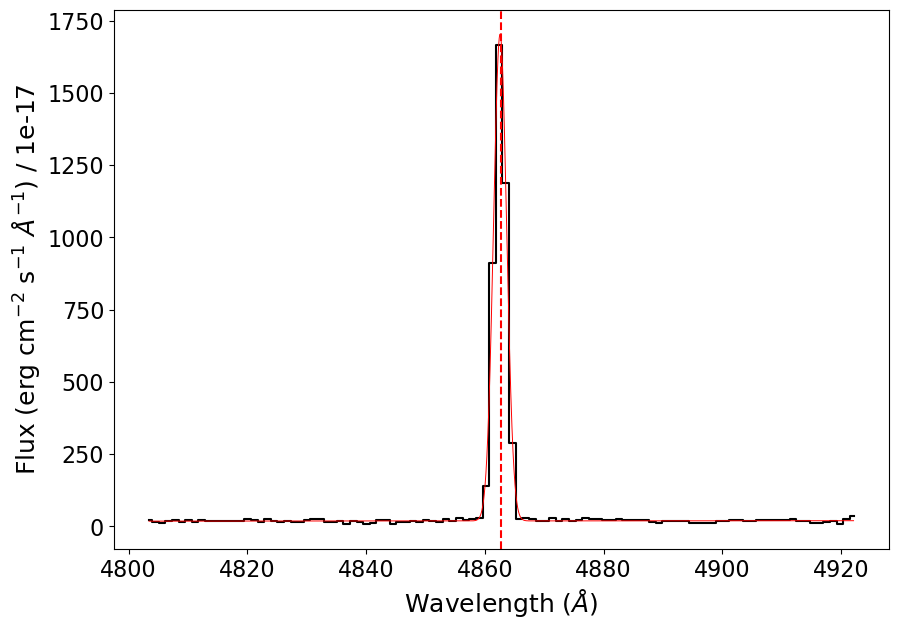

116.27188873291016


<CompoundModel(amplitude_0=1683.8308648, mean_0=4862.57038298, stddev_0=1.10516641, c0_1=-43.33741182, c1_1=0.01286107)>

In [177]:
# define the fitter
fit_g = fitting.LevMarLSQFitter()
# fit the model to the data
g = fit_g(g_total, w_hb, flux_hb, maxiter = 1000)

# define an array of wavelength values across our wavelength range with
#a high number of steps, to plot our model over our data
x_g = np.linspace(np.min(w_hb), np.max(w_hb), 10000)

# plot the model and the data
plt.figure(figsize=(10,7))
plt.step(w_hb, flux_hb, where='mid', color='k') # plot the data
plt.plot(x_g, g(x_g), color='red',linewidth = 0.7)
plt.axvline(x=4862.683, color='red', linestyle='--')
plt.xlabel(r"Wavelength ($\AA$)", fontsize=18)
plt.ylabel(r"Flux (erg cm$^{-2}$ s$^{-1}$ $\AA^{-1}$) / 1e-17", fontsize=18)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.show()

print(np.mean(flux_hb)*2)

g

In [178]:

def model(theta, wave):
    Amp, Mean, Std, c0, c1 = theta
    continuo = c0 + c1 * (wave)# - np.mean(wave))
    gaussiana = Amp * np.exp(-0.5 * ((wave - Mean) / Std)**2)
    return gaussiana + continuo


def lnlike(theta, wave, flux, flux_err):
    if np.any(~np.isfinite(flux_err)) or np.any(flux_err <= 0):
        return -np.inf

    modelo_total = model(theta, wave)
    residuos = flux - modelo_total
    chi_sq = np.sum((residuos / flux_err)**2)

    if not np.isfinite(chi_sq):
        return -np.inf

    return -0.5 * chi_sq


def lnprior(theta, wave, flux):
    Amp, Mean, Std, c0, c1 = theta

    r_flux = [np.min(flux), np.max(flux)]
    r_wave = [np.min(wave), np.max(wave)]
    mean_flux = np.median(flux)

    if (
        0.0 <= Amp <= 2.0 * r_flux[1] and
        (r_wave[0] - 10.0) <= Mean <= (r_wave[1] + 10.0) and
        0.1 <= Std <= 15.0 and
        0.0 <= c0 <= 2.0 * mean_flux and
        -10.0 <= c1 <= 10.0
    ):
        return 0.0

    return -np.inf


def lnpost(theta, wave, flux, flux_err):
    lp = lnprior(theta, wave, flux)
    if not np.isfinite(lp):
        return -np.inf

    ll = lnlike(theta, wave, flux, flux_err)
    if not np.isfinite(ll):
        return -np.inf

    return lp + ll



In [179]:
L_sliced_index = np.where((x_data >= 4862.683 - 60) & (x_data <= 4862.683 + 60))
wave_L = x_data[L_sliced_index]
flux_L = y_data[L_sliced_index]
flux_err_L = y_err[L_sliced_index]

# limpieza básica
mask = (
    np.isfinite(wave_L) &
    np.isfinite(flux_L) &
    np.isfinite(flux_err_L) &
    (flux_err_L > 0)
)

wave_L = wave_L[mask]
flux_L = flux_L[mask]
flux_err_L = flux_err_L[mask]

nsteps = 1000
ndim, nwalkers = 5, 20


amp0 = max(np.max(flux_L) - np.median(flux_L), 1e-3)
mean0 = 4862.683
std0 = 2.0
c0_0 = np.median(flux_L)
c1_0 = 0.0

p0 = np.array([amp0, mean0, std0, c0_0, c1_0])

start = p0 + 1e-3 * np.random.randn(nwalkers, ndim)

In [180]:
for i, pos in enumerate(start):
    lp = lnpost(pos, wave_L, flux_L, flux_err_L)
    print(i, pos, lp)

0 [1.64528276e+03 4.86268269e+03 1.99848844e+00 2.04307258e+01
 3.62448526e-04] -238879121.7744326
1 [1.64528235e+03 4.86268561e+03 1.99986242e+00 2.04330009e+01
 3.68977328e-04] -239439742.82687414
2 [1.64528279e+03 4.86268435e+03 2.00074356e+00 2.04334270e+01
 1.12907046e-03] -243474811.54442257
3 [1.64528003e+03 4.86268388e+03 2.00073342e+00 2.04303912e+01
 8.08824757e-04] -241843156.98330158
4 [ 1.64528243e+03  4.86268316e+03  1.99899524e+00  2.04321507e+01
 -2.05922246e-04] -236257131.22040966
5 [ 1.64528190e+03  4.86268364e+03  2.00069874e+00  2.04312284e+01
 -5.53483341e-04] -235107017.50260407
6 [1.64528188e+03 4.86268202e+03 1.99968828e+00 2.04334294e+01
 8.26863744e-04] -241549435.62234998
7 [ 1.64528169e+03  4.86268333e+03  2.00085861e+00  2.04311785e+01
 -6.11806765e-05] -237552524.6358379
8 [1.64528219e+03 4.86268297e+03 2.00019225e+00 2.04316945e+01
 1.24309709e-03] -243829376.69886708
9 [1.64528180e+03 4.86268256e+03 2.00083371e+00 2.04326947e+01
 8.20163206e-04] -241893

In [181]:
from getdist import plots, MCSamples
import zeus
from zeus import ChainManager

In [182]:
sampler = zeus.EnsembleSampler(
    nwalkers,
    ndim,
    lnpost,
    args=(wave_L, flux_L, flux_err_L)
)

sampler.run_mcmc(start, nsteps)

sampler.summary

Initialising ensemble of 20 walkers...
Sampling progress :   0%|          | 0/1000 [00:00<?, ?it/s]

Sampling progress : 100%|██████████| 1000/1000 [00:29<00:00, 34.07it/s]
Summary
-------
Number of Generations: 1000
Number of Parameters: 5
Number of Walkers: 20
Number of Tuning Generations: 30
Scale Factor: 0.178622
Mean Integrated Autocorrelation Time: 18.35
Effective Sample Size: 1090.19
Number of Log Probability Evaluations: 131240
Effective Samples per Log Probability Evaluation: 0.008307


In [183]:
chain = sampler.get_chain()  
burnin = int(0.3 * nsteps)
samples = sampler.get_chain(discard=burnin, flat=True)

N_samples_total = nwalkers * (nsteps - burnin)
samples.shape = (N_samples_total,ndim)

log_prob = sampler.get_log_prob(discard=burnin, flat=True)
best_index = np.argmax(log_prob)
best_theta = samples[best_index]
best_model = model(best_theta, wave_L)

theta_median = np.median(samples, axis=0)
theta_p16 = np.percentile(samples, 16, axis=0)
theta_p84 = np.percentile(samples, 84, axis=0)

theta_err_minus = theta_median - theta_p16
theta_err_plus  = theta_p84 - theta_median

param_names = ["Amp", "Mean", "Std", "c0", "c1"]

for i, name in enumerate(param_names):
    print(f"{name} = {theta_median[i]:.3f} "
          f"-{theta_err_minus[i]:.3f} +{theta_err_plus[i]:.3f}")


n_models = 100
idx = np.random.randint(len(samples), size=n_models)

models = [model(samples[i], wave_L) for i in idx]

Amp = 1683.663 -0.054 +0.053
Mean = 4862.571 -0.000 +0.000
Std = 1.143 -0.000 +0.000
c0 = 0.125 -0.094 +0.203
c1 = 0.000 -0.000 +0.000


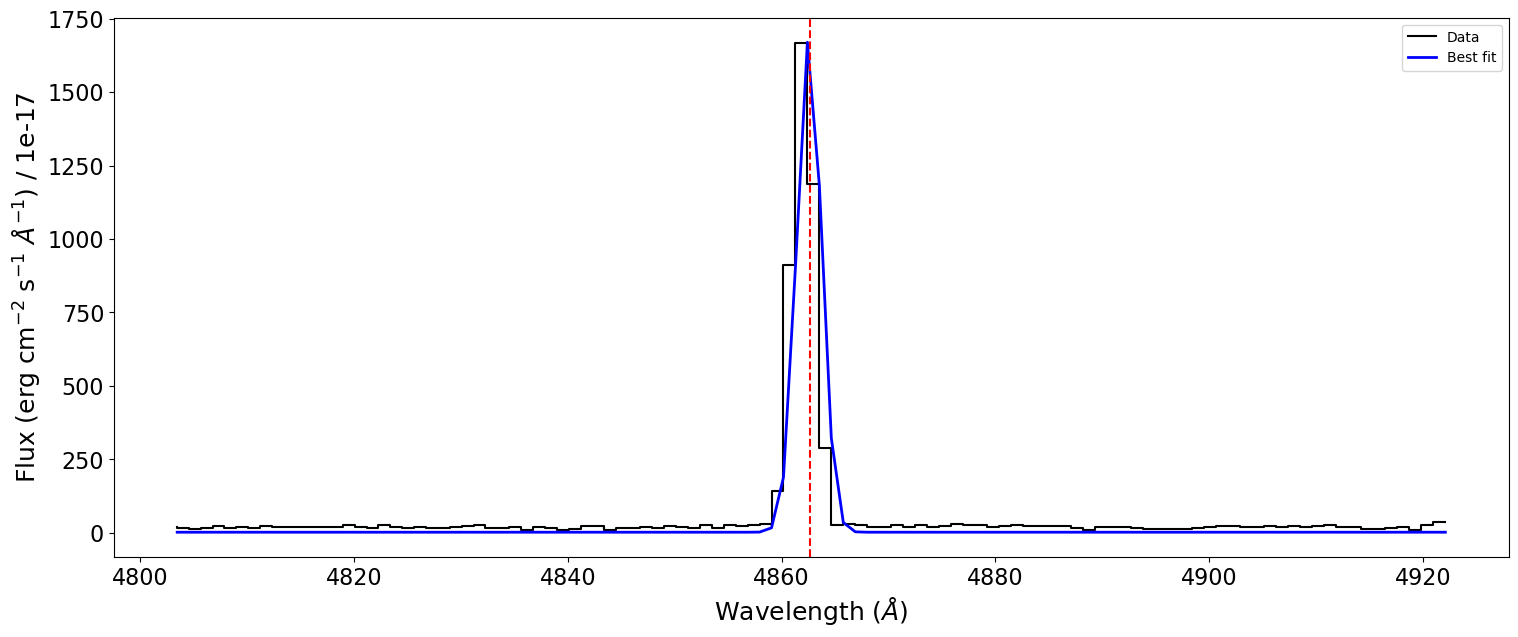

In [184]:
plt.figure(figsize=(18,7))

# Datos
plt.step(wave_L, flux_L, color="black", label="Data")

# Modelos MCMC
#for m in models:
#    plt.plot(wave_L, m, color="red", alpha=0.05)

# Mejor modelo
plt.plot(wave_L, best_model, color="blue", lw=2, label="Best fit")
plt.legend()
plt.axvline(x=4862.683, color='red', linestyle='--')
plt.xlabel(r"Wavelength ($\AA$)", fontsize=18)
plt.ylabel(r"Flux (erg cm$^{-2}$ s$^{-1}$ $\AA^{-1}$) / 1e-17", fontsize=18)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.show()

In [185]:
model_samples = np.array([model(s, wave_L) for s in samples[::50]])

model_median = np.median(model_samples, axis=0)
model_p16 = np.percentile(model_samples, 16, axis=0)
model_p84 = np.percentile(model_samples, 84, axis=0)

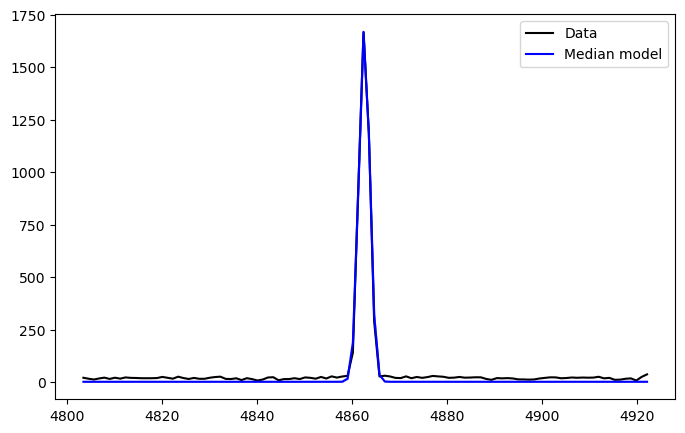

In [186]:
plt.figure(figsize=(8,5))

plt.plot(wave_L, flux_L, color="black", label="Data")
plt.plot(wave_L, model_median, color="blue", label="Median model")

plt.fill_between(wave_L, model_p16, model_p84, color="blue", alpha=0.3)

plt.legend()
plt.show()

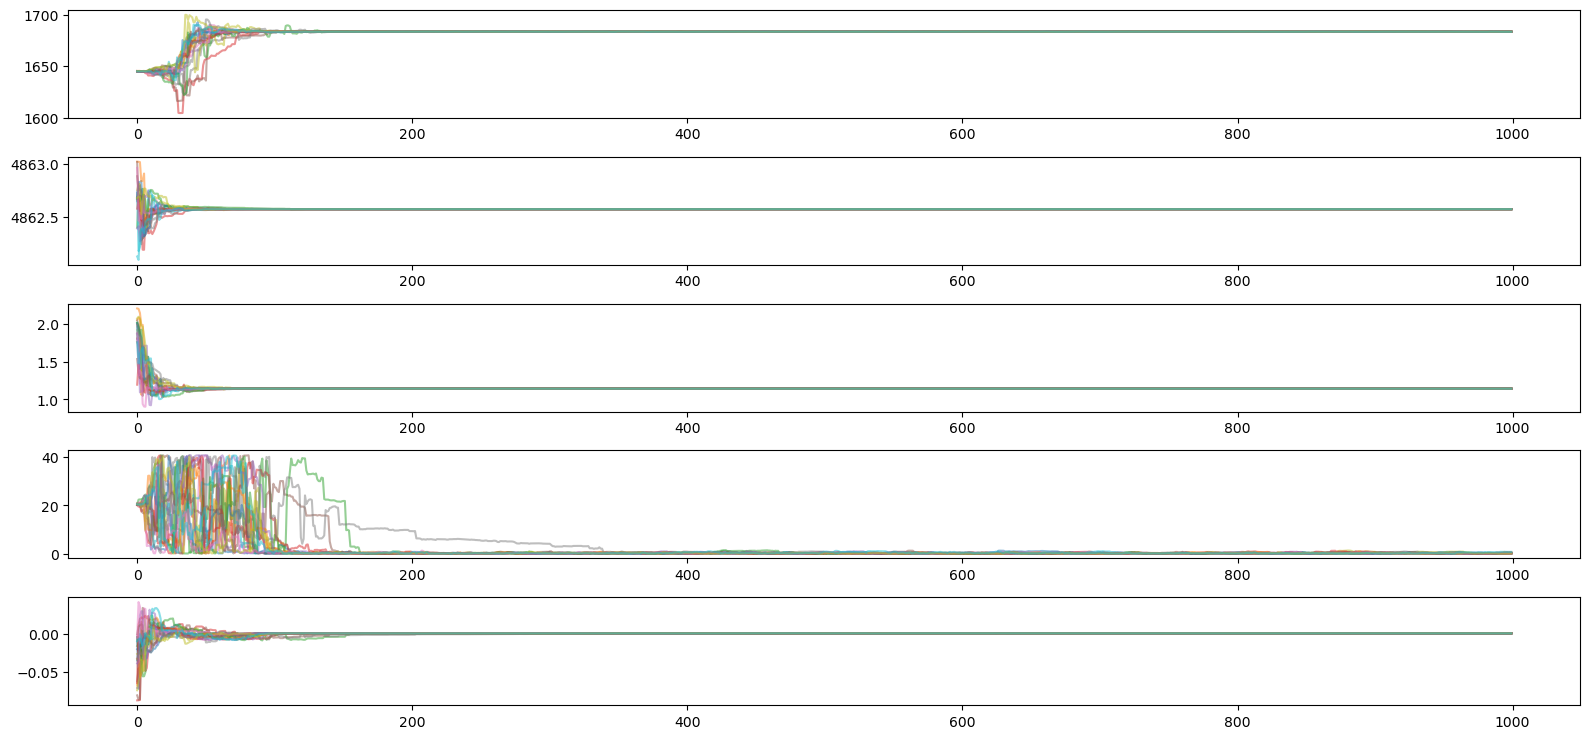

In [187]:
plt.figure(figsize=(16,1.5*ndim))
for n in range(ndim):
    plt.subplot2grid((ndim, 1), (n, 0))
    plt.plot(sampler.get_chain()[:,:,n], alpha=0.5)
plt.tight_layout()
plt.show()

Removed no burn in


auto bandwidth for c1 very small or failed (h=0.0007044330566565128,N_eff=5420.4342461851265). Using fallback (h=0.003058333006241173)
auto bandwidth for c1 very small or failed (h=0.0007044330566565128,N_eff=5420.4342461851265). Using fallback (h=0.003058333006241173)


parameter values:
       Amplitud : 1683.663 +- 0.054
         Center : 4862.571 +- 0.000
            Std : 1.143 +- 0.000
             c1 : 0.202 +- 0.347
             c0 : 0.000 +- 0.000
\begin{tabular} { l  c}

 Parameter &  68\% limits\\
\hline
{\boldmath$Amplitud       $} & $1683.663\pm 0.054         $\\

{\boldmath$Center         $} & $4862.570519\pm 0.000025   $\\

{\boldmath$Std            $} & $1.142745\pm 0.000040      $\\

{\boldmath$c1             $} & $0.202^{+0.029}_{-0.21}    $\\

{\boldmath$c0             $} & $0.000351^{+0.000046}_{-0.0000090}$\\
\hline
\end{tabular}


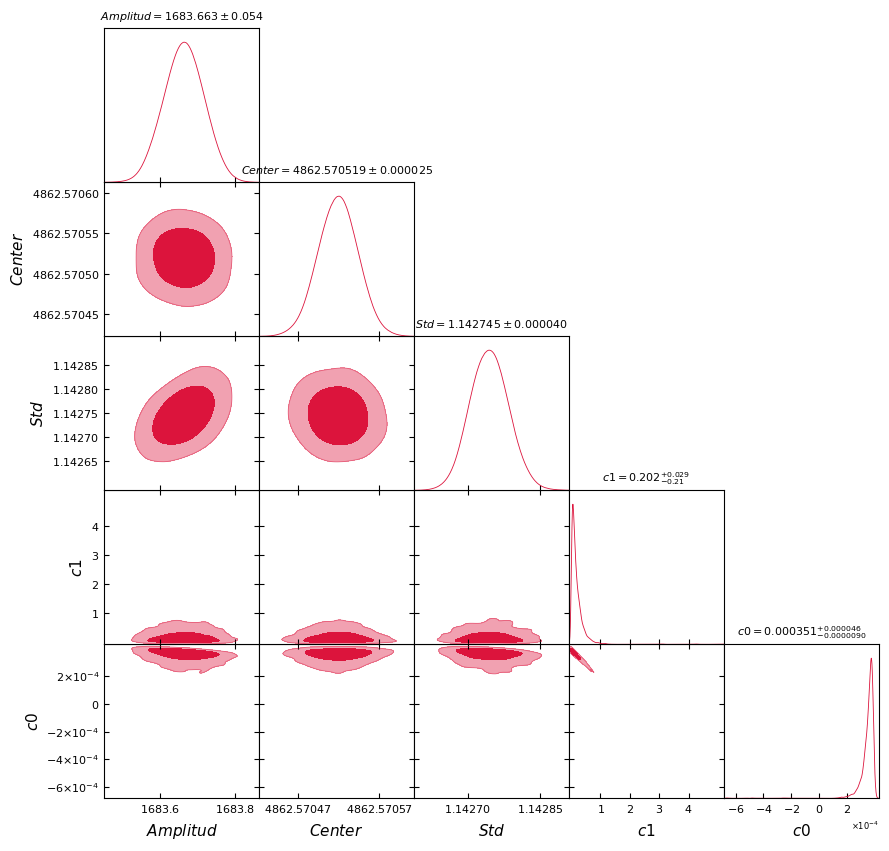

In [188]:
parameters = [r"Amplitud", r"Center", r"Std", r"c1", r"c0"]

chain = sampler.get_chain(flat=True, discard=nsteps//4, thin=1)



%matplotlib inline
tag = 'GDplot'
path = ''
GDsamples = MCSamples(samples=chain, names=parameters,
                          labels=parameters, name_tag=tag #,
                          # ranges={r"\Omega_m":[0.0, None]}
                          )

g = plots.getSubplotPlotter() #width_inch=4
g.settings.num_plot_contours = 2
g.triangle_plot(GDsamples, filled=True, title_limit=1,
            contour_colors=['crimson']
            # , param_limits={r"\alpha":[32.8, 33.7]
                        # , r"\beta":[4.7, 5.35]
                        # , r"h":[0.6, 0.85]
                        # , r"\Omega_m":[0.0, 0.52]
                        # , r"w_0":[-2.1, -0.2]
                        # }
            )
g.export(path)


t = GDsamples.getTable(limit=1).tableTex()
theta = GDsamples.getMeans()

# Print parameter values
print('parameter values:')
for name, col in zip(parameters, chain.transpose()):
  print('%15s : %.3f +- %.3f' % (name, col.mean(), col.std()))

print(t)
